# Metricas de Generacion en RAG
## con ejemplos sinteticos del Boletin Oficial de Salta

**Diplomatura en IA · UBA / FIUBA · Clase 03**

---

Este notebook demuestra dos metricas de evaluacion de la etapa de **generacion** en un sistema RAG.  
No requiere LLM ni Colab avanzado: todo el calculo se hace sobre **respuestas sinteticas prefabricadas**  
que simulan distintos niveles de calidad del modelo.

| Metrica | Que mide | Rango |
|---|---|---|
| **Token Overlap** | Si la respuesta contiene los terminos correctos | 0 a 1 |
| **Context Faithfulness** | Si la respuesta viene del contexto o es alucinacion | 0 a 1 |

**Corpus de referencia:** Boletin Oficial de Salta · Edicion N° 21.922 · 31/03/2025


---
## Setup


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.facecolor":"#f8fafc","axes.facecolor":"#ffffff",
    "axes.grid":True,"grid.alpha":0.3,
    "axes.titlesize":12,"axes.labelsize":10
})

# Paleta semantica
ROJO   = '#EF4444'   # score bajo  (< 0.4)
AMBAR  = '#F59E0B'   # score medio (0.4 - 0.7)
VERDE  = '#10B981'   # score alto  (> 0.7)

def color_score(s):
    if s >= 0.7: return VERDE
    if s >= 0.4: return AMBAR
    return ROJO

print('OK')


OK


---
## Funciones base

Ambas metricas comparten la misma funcion de tokenizacion:  
extraer palabras con significado (nombres, numeros, terminos tecnicos)  
y descartar stopwords (de, la, el, en, y...).


In [2]:
STOP = {
    'de','la','el','en','y','a','los','las','del','se','que','por','con',
    'un','una','es','al','lo','su','fue','para','como','pero','sin','ha',
    'no','si','son','ya','o','e','n','al','desde','hasta','sobre','segun',
    'tanto','bien','este','esta','dicho','presenta','establece','dispone',
    'mediante','conforme','tanto','cuya','cuyo','mismo','misma','forma',
}

def tokenizar(texto: str) -> set:
    """Palabras significativas en minusculas, sin signos."""
    return {
        re.sub(r'[^\w]','', t).lower()
        for t in texto.split()
        if len(t) > 2 and t.lower().strip('.,;:-()') not in STOP
    } - {''}


def token_overlap(respuesta_gen: str, respuesta_ref: str) -> float:
    """
    TOKEN OVERLAP
    Fraccion de tokens de la referencia que aparecen en la respuesta generada.

    Formula:
        TO = | tokens(gen) ∩ tokens(ref) | / | tokens(ref) |

    Valor 1.0 -> el LLM incluyo todos los terminos esperados.
    Valor 0.0 -> la respuesta no contiene ningun termino de la referencia.
    """
    gen = tokenizar(respuesta_gen)
    ref = tokenizar(respuesta_ref)
    if not ref:
        return 0.0
    return round(len(gen & ref) / len(ref), 3)


def context_faithfulness(respuesta_gen: str, contexto: str) -> float:
    """
    CONTEXT FAITHFULNESS
    Fraccion de tokens de la respuesta que estaban en el contexto recuperado.

    Formula:
        CF = | tokens(gen) ∩ tokens(ctx) | / | tokens(gen) |

    Valor 1.0 -> toda la respuesta viene del contexto, sin alucinacion.
    Valor 0.0 -> el LLM invento todo: ninguna palabra suya estaba en el contexto.
    """
    gen = tokenizar(respuesta_gen)
    ctx = tokenizar(contexto)
    if not gen:
        return 0.0
    return round(len(gen & ctx) / len(gen), 3)


# Test rapido
print("Token Overlap demo:")
print("  ref='Bocanera DNI 31904457', gen='Bruno Bocanera DNI 31904457 Salta'")
print(f"  Score: {token_overlap('Bruno Bocanera DNI 31904457 Salta', 'Bocanera DNI 31904457')}")
print()
print("Context Faithfulness demo:")
print("  gen='Legajo 13818 Seguridad', ctx='Legajo Personal 13818 Cuerpo Seguridad Escalafon General'")
print(f"  Score: {context_faithfulness('Legajo 13818 Seguridad', 'Legajo Personal 13818 Cuerpo Seguridad Escalafon General')}")


Token Overlap demo:
  ref='Bocanera DNI 31904457', gen='Bruno Bocanera DNI 31904457 Salta'
  Score: 1.0

Context Faithfulness demo:
  gen='Legajo 13818 Seguridad', ctx='Legajo Personal 13818 Cuerpo Seguridad Escalafon General'
  Score: 1.0


---
# METRICA 1 — Token Overlap

## Que mide

Compara lo que el LLM **dijo** contra lo que **deberia haber dicho**.

```
                  tokens(respuesta_generada) ∩ tokens(respuesta_esperada)
Token Overlap =  ────────────────────────────────────────────────────────
                             tokens(respuesta_esperada)
```

**Cuatro categorias de resultado:**

| Score | Categoria | Significado |
|---|---|---|
| 0.85 – 1.0 | Perfecto | Respuesta completa y precisa |
| 0.50 – 0.84 | Bueno | Respuesta parcialmente correcta |
| 0.20 – 0.49 | Parcial | Captura el tema pero le faltan datos clave |
| 0.00 – 0.19 | Pobre | Respuesta incorrecta, vaga o alucinada |


In [3]:
# ── 25 ejemplos sinteticos de Token Overlap ──────────────────────────────
# Cada ejemplo simula una respuesta real del LLM para una consulta legal.
# 'ref' = respuesta esperada (ground truth)
# 'gen' = respuesta que genero el LLM (simulada)

EJEMPLOS_TO = [

  # ─── PERFECTOS: el LLM captura todos los terminos clave ─────────────────
  {"id": 1, "categoria": "Perfecto",
   "descripcion": "LLM reproduce con precision nombre y DNI",
   "query": "Quien fue designado titular del Registro Notarial N 11?",
   "ref": "Bruno Jose Bocanera DNI 31904457 Registro Notarial 11 Salta",
   "gen": "El Escribano Bruno Jose Bocanera con DNI 31904457 fue designado titular del Registro Notarial N 11 con asiento en la ciudad de Salta."},

  {"id": 2, "categoria": "Perfecto",
   "descripcion": "Sanciones de la ley enunciadas completas",
   "query": "Cuales son las sanciones de la Ley 8488?",
   "ref": "apercibimiento multa 50000 100000 unidades tributarias",
   "gen": "Las sanciones son apercibimiento y multa de entre 50000 y 100000 unidades tributarias."},

  {"id": 3, "categoria": "Perfecto",
   "descripcion": "Datos personales de retiro correctos y completos",
   "query": "Que legajo y escalafon tiene Carlos Figueroa Rueda?",
   "ref": "Legajo 13818 Cuerpo Seguridad Escalafon General",
   "gen": "Figueroa Rueda tiene Legajo Personal 13818 del Cuerpo Seguridad Escalafon General."},

  {"id": 4, "categoria": "Perfecto",
   "descripcion": "Renuncia con nombre y DNI correctos",
   "query": "Quien renuncio al cargo de Secretaria de Justicia?",
   "ref": "Maria Veronica Saicha Ibanez DNI 20339284 Secretaria Justicia",
   "gen": "La Dra Maria Veronica Saicha Ibanez DNI 20339284 renuncio al cargo de Secretaria de Justicia."},

  {"id": 5, "categoria": "Perfecto",
   "descripcion": "Fecha de afectacion exacta con condicion",
   "query": "Hasta cuando dura la afectacion de Salazar Arce?",
   "ref": "31 diciembre 2025 necesidades servicio",
   "gen": "La afectacion dura hasta el 31 de diciembre de 2025 o mientras duren las necesidades de servicio."},

  {"id": 6, "categoria": "Perfecto",
   "descripcion": "DNI correcto y con datos de clase",
   "query": "Cual es el DNI de Alberto del Milagro Bonifacio?",
   "ref": "25122446 Legajo 13403 Clase 1976",
   "gen": "El Suboficial Mayor Alberto del Milagro Bonifacio tiene DNI 25122446 Legajo 13403 y es de Clase 1976."},

  {"id": 7, "categoria": "Perfecto",
   "descripcion": "Ministerio y expediente del Decreto 167",
   "query": "A que ministerio pertenece el Decreto 167?",
   "ref": "Ministerio Gobierno Derechos Humanos Trabajo expediente 0030041-32996",
   "gen": "El Decreto 167 pertenece al Ministerio de Gobierno Derechos Humanos y Trabajo con expediente 0030041-32996."},


  # ─── BUENOS: captura la mayor parte pero le falta algun dato ────────────
  {"id": 8, "categoria": "Bueno",
   "descripcion": "Nombre correcto pero omite el DNI",
   "query": "Quien es el titular del Registro Notarial N 11?",
   "ref": "Bruno Jose Bocanera DNI 31904457",
   "gen": "El Escribano Bruno Jose Bocanera es el titular del Registro Notarial N 11."},

  {"id": 9, "categoria": "Bueno",
   "descripcion": "Afectacion correcta pero sin DNI",
   "query": "Quien fue afectada al Concejo Deliberante en la DA 111?",
   "ref": "Testa Noelia Alejandra DNI 29640497 Educacion Concejo Deliberante",
   "gen": "La Sra Noelia Alejandra Testa del Ministerio de Educacion fue afectada al Concejo Deliberante de Salta."},

  {"id": 10, "categoria": "Bueno",
   "descripcion": "Sancion correcta pero solo menciona la multa maxima",
   "query": "Que sanciones aplica la Ley 8488 a cursos ilegales?",
   "ref": "suspension inmediata apercibimiento multa 50000 100000 unidades tributarias",
   "gen": "Se ordena la suspension inmediata y se aplica apercibimiento o multa de hasta 100000 unidades tributarias."},

  {"id": 11, "categoria": "Bueno",
   "descripcion": "Datos del retiro de Gomez Posse parcialmente correctos",
   "query": "Que legajo y clase tiene Claudia Gomez Posse?",
   "ref": "Legajo 13976 Clase 1982 Escalafon General",
   "gen": "La Suboficial Mayor Claudia Elizabet Gomez Posse tiene Legajo 13976 y es de Clase 1982."},

  {"id": 12, "categoria": "Bueno",
   "descripcion": "Responde el cargo con aproximacion pero sin datos secundarios",
   "query": "Que cargo tenia Saicha Ibanez al renunciar?",
   "ref": "Secretaria Justicia DNI 20339284 Ministerio Seguridad",
   "gen": "La Dra Saicha Ibanez ocupaba el cargo de Secretaria de Justicia al momento de la renuncia."},


  # ─── PARCIALES: el tema es correcto pero faltan datos especificos ────────
  {"id": 13, "categoria": "Parcial",
   "descripcion": "Menciona al escribano pero no el numero de registro",
   "query": "A que registro fue designado el Escribano Bocanera?",
   "ref": "Registro Notarial 11 ciudad Salta",
   "gen": "El Escribano Bocanera fue designado titular de un registro notarial en la provincia de Salta."},

  {"id": 14, "categoria": "Parcial",
   "descripcion": "Solo menciona Retiro Voluntario sin datos del agente",
   "query": "Que clase y cuerpo tiene Jorge Felipe Salas?",
   "ref": "Clase 1980 Legajo 16601 Cuerpo Seguridad Escalafon General",
   "gen": "Jorge Felipe Edgardo Salas fue puesto en situacion de Retiro Voluntario del Cuerpo Seguridad."},

  {"id": 15, "categoria": "Parcial",
   "descripcion": "Fecha correcta pero omite la condicion alternativa",
   "query": "Hasta cuando dura la afectacion de Noelia Testa?",
   "ref": "31 diciembre 2025 necesidades servicio primero suceda",
   "gen": "La afectacion de Noelia Testa al Concejo Deliberante vence el 31 de diciembre de 2025."},

  {"id": 16, "categoria": "Parcial",
   "descripcion": "Menciona la ley correcta pero da el Articulo equivocado",
   "query": "Que establece el Articulo 1 de la Ley 8488?",
   "ref": "cursos salud educacion Salta autorizados homologados certificados Autoridades Provinciales Nacionales",
   "gen": "El Articulo 1 de la Ley 8488 establece que el Poder Ejecutivo determinara la Autoridad de Aplicacion de Salta."},

  {"id": 17, "categoria": "Parcial",
   "descripcion": "Nombres de firmantes incompletos",
   "query": "Quienes firmaron el Decreto 168?",
   "ref": "Saenz Sola Usandivaras Lopez Morillo",
   "gen": "El Decreto 168 fue firmado por el Gobernador Saenz y el Ministro Lopez Morillo."},


  # ─── POBRES: respuesta incorrecta, alucinada o evasiva ───────────────────
  {"id": 18, "categoria": "Pobre",
   "descripcion": "Confunde legajos entre personas del mismo template",
   "query": "Cual es el legajo de Julio Blas Guaimas?",
   "ref": "Legajo 13381 Clase 1970",
   "gen": "El legajo de Julio Blas Guaimas es el 13818 segun el decreto de retiro voluntario."},

  {"id": 19, "categoria": "Pobre",
   "descripcion": "LLM inventa un numero de expediente",
   "query": "Cual es el expediente del Decreto 171?",
   "ref": "0140044-113886/2024-0",
   "gen": "El Decreto 171 tiene el expediente N 0140044-999999/2023-0 segun registros del ministerio."},

  {"id": 20, "categoria": "Pobre",
   "descripcion": "DNI de persona distinta aplicado a otra",
   "query": "Cual es el DNI de Claudia Elizabet Gomez Posse?",
   "ref": "29164778 Legajo 13976",
   "gen": "El DNI de Claudia Gomez Posse es 25122446 de acuerdo al decreto correspondiente."},

  {"id": 21, "categoria": "Pobre",
   "descripcion": "Organismo validador inventado",
   "query": "Que organismo valido la liquidacion de retiro de Diego Rico?",
   "ref": "ANSES Resolucion 108/2025 Ministerio Seguridad Justicia",
   "gen": "La liquidacion fue validada por la Secretaria de Hacienda y el Ministerio de Finanzas Publicas."},

  {"id": 22, "categoria": "Pobre",
   "descripcion": "El LLM se niega aunque el dato existe en el corpus",
   "query": "Cuantos anos de adjuncion tuvo Bocanera para obtener el Registro?",
   "ref": "10 anos adjuncion Ley 6486",
   "gen": "No tengo informacion sobre los anos de adjuncion requeridos en el expediente analizado."},

  {"id": 23, "categoria": "Pobre",
   "descripcion": "Ciudad incorrecta para el asiento del registro",
   "query": "En que ciudad tiene asiento el Registro Notarial de Bocanera?",
   "ref": "ciudad Salta",
   "gen": "El Registro Notarial del Escribano Bocanera tiene asiento en la ciudad de San Salvador de Jujuy."},

  {"id": 24, "categoria": "Pobre",
   "descripcion": "Persona inventada en respuesta a la DA 111",
   "query": "Quien fue afectada al Concejo Deliberante segun la DA 111?",
   "ref": "Testa Noelia Alejandra DNI 29640497 Educacion",
   "gen": "Segun la Decision Administrativa 111 la Sra Rodriguez Maria Elena del Ministerio de Salud fue afectada al Concejo."},

  {"id": 25, "categoria": "Pobre",
   "descripcion": "Respuesta completamente generica sin datos",
   "query": "Que dispone el Decreto 174 sobre Diego Fernando Rico?",
   "ref": "Retiro Voluntario Sargento Ayudante Penitenciario DNI 30636175 Legajo 1908",
   "gen": "El Decreto 174 establece las condiciones generales para el retiro del personal de seguridad de la provincia."},

]

print(f'Ejemplos cargados: {len(EJEMPLOS_TO)}')


Ejemplos cargados: 25


In [4]:
# ── Calcular Token Overlap para cada ejemplo ──────────────────────────────
for e in EJEMPLOS_TO:
    e['score'] = token_overlap(e['gen'], e['ref'])
    e['tokens_ref'] = tokenizar(e['ref'])
    e['tokens_gen'] = tokenizar(e['gen'])
    e['intersect']  = e['tokens_ref'] & e['tokens_gen']

df_to = pd.DataFrame(EJEMPLOS_TO)[['id','categoria','descripcion','score']]
print(df_to.to_string(index=False))
print()
print(f"Promedio Token Overlap: {df_to['score'].mean():.3f}")
print()
print("Por categoria:")
print(df_to.groupby('categoria')['score'].agg(['mean','min','max','count']).round(3))


 id categoria                                                   descripcion  score
  1  Perfecto                      LLM reproduce con precision nombre y DNI  1.000
  2  Perfecto                      Sanciones de la ley enunciadas completas  1.000
  3  Perfecto              Datos personales de retiro correctos y completos  1.000
  4  Perfecto                           Renuncia con nombre y DNI correctos  1.000
  5  Perfecto                      Fecha de afectacion exacta con condicion  1.000
  6  Perfecto                             DNI correcto y con datos de clase  1.000
  7  Perfecto                       Ministerio y expediente del Decreto 167  1.000
  8     Bueno                             Nombre correcto pero omite el DNI  0.600
  9     Bueno                              Afectacion correcta pero sin DNI  0.750
 10     Bueno           Sancion correcta pero solo menciona la multa maxima  0.875
 11     Bueno        Datos del retiro de Gomez Posse parcialmente correctos  0.667
 12 

### Calculo detallado — 5 casos representativos

Vemos paso a paso como se computa la metrica para entender que mide en cada caso.


In [5]:
# ── Mostrar calculo paso a paso para casos representativos ───────────────
CASOS_DETALLE = [1, 8, 14, 18, 22]   # perfecto / bueno / parcial / pobre / pobre-evasivo

for eid in CASOS_DETALLE:
    e = next(x for x in EJEMPLOS_TO if x['id'] == eid)
    print('=' * 65)
    print(f"Ejemplo {e['id']} [{e['categoria']}] — {e['descripcion']}")
    print(f"  Pregunta : {e['query']}")
    print(f"  REF      : {e['ref']}")
    print(f"  GEN      : {e['gen'][:80]}")
    print(f"  tokens_ref ({len(e['tokens_ref'])}): {sorted(e['tokens_ref'])}")
    print(f"  tokens_gen ({len(e['tokens_gen'])}): {sorted(e['tokens_gen'])}")
    print(f"  intersect  ({len(e['intersect'])}): {sorted(e['intersect'])}")
    print(f"  SCORE = {len(e['intersect'])} / {len(e['tokens_ref'])} = {e['score']:.3f}")
    print()


Ejemplo 1 [Perfecto] — LLM reproduce con precision nombre y DNI
  Pregunta : Quien fue designado titular del Registro Notarial N 11?
  REF      : Bruno Jose Bocanera DNI 31904457 Registro Notarial 11 Salta
  GEN      : El Escribano Bruno Jose Bocanera con DNI 31904457 fue designado titular del Regi
  tokens_ref (8): ['31904457', 'bocanera', 'bruno', 'dni', 'jose', 'notarial', 'registro', 'salta']
  tokens_gen (13): ['31904457', 'asiento', 'bocanera', 'bruno', 'ciudad', 'designado', 'dni', 'escribano', 'jose', 'notarial', 'registro', 'salta', 'titular']
  intersect  (8): ['31904457', 'bocanera', 'bruno', 'dni', 'jose', 'notarial', 'registro', 'salta']
  SCORE = 8 / 8 = 1.000

Ejemplo 8 [Bueno] — Nombre correcto pero omite el DNI
  Pregunta : Quien es el titular del Registro Notarial N 11?
  REF      : Bruno Jose Bocanera DNI 31904457
  GEN      : El Escribano Bruno Jose Bocanera es el titular del Registro Notarial N 11.
  tokens_ref (5): ['31904457', 'bocanera', 'bruno', 'dni', 'jose']


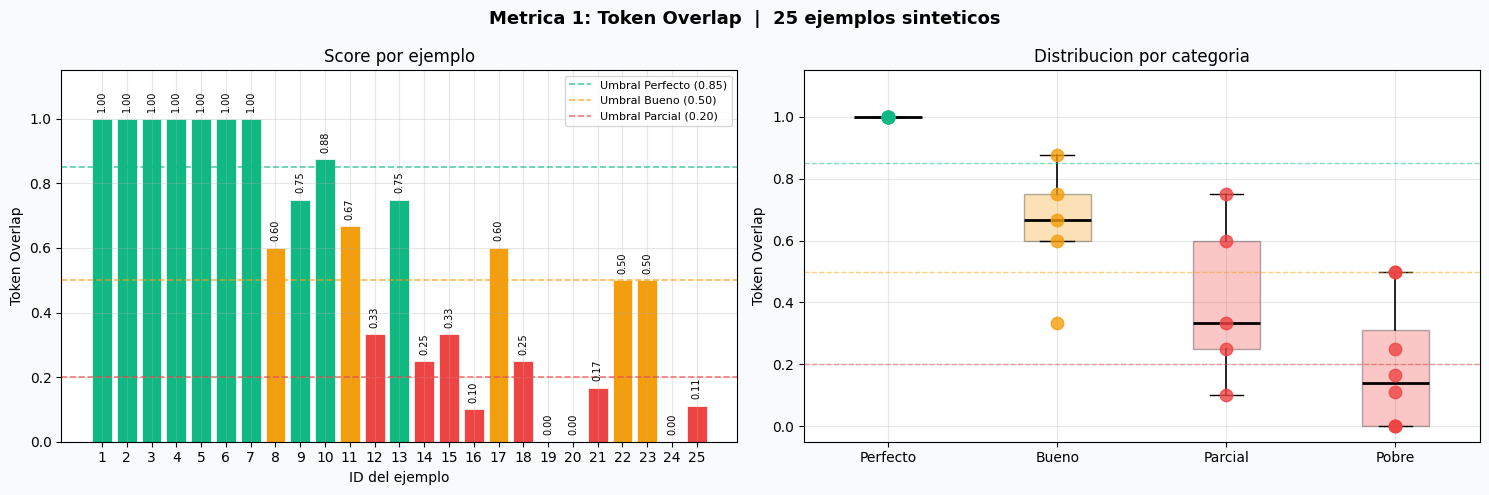

Promedio global: 0.551
  Perfecto   n=7  media=1.000
  Bueno      n=5  media=0.645
  Parcial    n=5  media=0.407
  Pobre      n=8  media=0.191


In [6]:
# ── Visualizacion Token Overlap ───────────────────────────────────────────
scores = [e['score'] for e in EJEMPLOS_TO]
ids    = [e['id']    for e in EJEMPLOS_TO]
cats   = [e['categoria'] for e in EJEMPLOS_TO]
colores_barra = [color_score(s) for s in scores]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Metrica 1: Token Overlap  |  25 ejemplos sinteticos',
             fontweight='bold', fontsize=13)

# Panel izquierdo: score por ejemplo
ax = axes[0]
bars = ax.bar(ids, scores, color=colores_barra, edgecolor='white', linewidth=0.5)
ax.axhline(0.85, color=VERDE,  ls='--', lw=1.2, alpha=0.7, label='Umbral Perfecto (0.85)')
ax.axhline(0.50, color=AMBAR,  ls='--', lw=1.2, alpha=0.7, label='Umbral Bueno (0.50)')
ax.axhline(0.20, color=ROJO,   ls='--', lw=1.2, alpha=0.7, label='Umbral Parcial (0.20)')
ax.set_xlabel('ID del ejemplo')
ax.set_ylabel('Token Overlap')
ax.set_title('Score por ejemplo')
ax.set_ylim(0, 1.15)
ax.set_xticks(ids)
ax.legend(fontsize=8)

# Anotar score sobre cada barra
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)

# Panel derecho: distribucion por categoria
ax = axes[1]
orden_cat = ['Perfecto', 'Bueno', 'Parcial', 'Pobre']
colores_cat = {c: color_score({'Perfecto':0.9,'Bueno':0.65,'Parcial':0.35,'Pobre':0.1}[c])
               for c in orden_cat}
for cat in orden_cat:
    vals = [e['score'] for e in EJEMPLOS_TO if e['categoria'] == cat]
    ax.scatter([cat]*len(vals), vals, color=colores_cat[cat],
               s=80, alpha=0.8, zorder=3)
    ax.boxplot(vals, positions=[orden_cat.index(cat)],
               widths=0.4, patch_artist=True,
               boxprops=dict(facecolor=colores_cat[cat], alpha=0.3),
               medianprops=dict(color='black', lw=2),
               whiskerprops=dict(lw=1.2),
               flierprops=dict(marker=''))
ax.set_xticks(range(len(orden_cat)))
ax.set_xticklabels(orden_cat)
ax.set_ylabel('Token Overlap')
ax.set_title('Distribucion por categoria')
ax.set_ylim(-0.05, 1.15)
ax.axhline(0.85, color=VERDE, ls='--', lw=1, alpha=0.5)
ax.axhline(0.50, color=AMBAR, ls='--', lw=1, alpha=0.5)
ax.axhline(0.20, color=ROJO,  ls='--', lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig('token_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Promedio global:', round(np.mean(scores), 3))
for cat in orden_cat:
    vals = [e['score'] for e in EJEMPLOS_TO if e['categoria'] == cat]
    print(f'  {cat:10} n={len(vals)}  media={np.mean(vals):.3f}')


---
# METRICA 2 — Context Faithfulness

## Que mide

Detecta si el LLM uso el contexto recuperado o **genero informacion propia** (alucinacion).

```
                       tokens(respuesta_generada) ∩ tokens(contexto_recuperado)
Context Faithfulness = ─────────────────────────────────────────────────────────
                                    tokens(respuesta_generada)
```

**La diferencia con Token Overlap:** Token Overlap compara contra la *respuesta correcta*.  
Context Faithfulness compara contra el *contexto que recibio el LLM*.
Una respuesta puede ser correcta pero infiel al contexto (el LLM uso su memoria).  
Y puede ser fiel al contexto pero incorrecta (el retrieval devolvio el chunk equivocado).

| Score | Categoria | Significado |
|---|---|---|
| 0.80 – 1.0 | Fiel | Toda la respuesta se basa en el contexto |
| 0.50 – 0.79 | Parcialmente fiel | Mezcla contexto con conocimiento propio |
| 0.20 – 0.49 | Sospechoso | La mayor parte no vino del contexto |
| 0.00 – 0.19 | Alucinacion | El LLM ignoro el contexto y genero todo el solo |


In [7]:
# ── 25 ejemplos sinteticos de Context Faithfulness ──────────────────────
# 'contexto' = lo que el retrieval devolvio al LLM
# 'gen'      = lo que el LLM respondio

EJEMPLOS_CF = [

  # ─── FIELES: la respuesta viene casi completamente del contexto ──────────
  {"id": 1, "categoria": "Fiel",
   "descripcion": "Copia casi literal del contexto recuperado",
   "query": "Cual es el legajo de Figueroa Rueda?",
   "contexto": "Disponese Retiro Voluntario Suboficial Principal Carlos Cristian Figueroa Rueda DNI 27465890 Clase 1979 Legajo Personal 13818 Cuerpo Seguridad Escalafon General",
   "gen": "El Suboficial Principal Figueroa Rueda tiene Legajo Personal 13818 del Cuerpo Seguridad Escalafon General."},

  {"id": 2, "categoria": "Fiel",
   "descripcion": "Respuesta directa usando terminos exactos del contexto",
   "query": "Hasta cuando dura la afectacion de Salazar Arce?",
   "contexto": "Autorizar afectacion Salazar Arce Carolina Marianela DNI 30221491 Concejo Deliberante Ciudad Salta 01 enero 2025 hasta 31 diciembre 2025 mientras duren necesidades servicio",
   "gen": "La afectacion de Salazar Arce al Concejo Deliberante dura hasta el 31 de diciembre de 2025 o mientras duren las necesidades de servicio."},

  {"id": 3, "categoria": "Fiel",
   "descripcion": "Sanciones parafraseadas pero con todos los valores del contexto",
   "query": "Que sanciones establece la Ley 8488?",
   "contexto": "persona responsable sera pasible apercibimiento multa 50000 100000 unidades tributarias suspension inmediata dictado",
   "gen": "La persona responsable sera pasible de apercibimiento y multa de entre 50000 y 100000 unidades tributarias."},

  {"id": 4, "categoria": "Fiel",
   "descripcion": "Datos de Gomez Posse extraidos fielmente del contexto",
   "query": "Que legajo y clase tiene Claudia Gomez Posse?",
   "contexto": "Suboficial Mayor Claudia Elizabet Gomez Posse DNI 29164778 Legajo Personal 13976 Clase 1982 Cuerpo Seguridad Escalafon General",
   "gen": "Claudia Elizabet Gomez Posse tiene Legajo Personal 13976 y es de Clase 1982."},

  {"id": 5, "categoria": "Fiel",
   "descripcion": "Renuncia de Saicha Ibanez transcripta del contexto",
   "query": "Quien renuncio al cargo de Secretaria de Justicia?",
   "contexto": "Aceptase renuncia Dra Maria Veronica Saicha Ibanez DNI 20339284 cargo Secretaria Justicia dandoseles gracias servicios prestados",
   "gen": "La Dra Maria Veronica Saicha Ibanez DNI 20339284 presento su renuncia al cargo de Secretaria de Justicia."},

  {"id": 6, "categoria": "Fiel",
   "descripcion": "Designacion del escribano fiel al fragmento",
   "query": "Quien fue designado titular del Registro Notarial N 11?",
   "contexto": "Designase Escribano Bruno Jose Bocanera DNI 31904457 titular Registro Notarial 11 asiento ciudad Salta merito razones considerando",
   "gen": "El Escribano Bruno Jose Bocanera DNI 31904457 fue designado titular del Registro Notarial 11 con asiento en Salta."},

  {"id": 7, "categoria": "Fiel",
   "descripcion": "Afectacion de Testa directamente del contexto",
   "query": "Hasta cuando dura la afectacion de Testa?",
   "contexto": "Autorizar afectacion Testa Noelia Alejandra DNI 29640497 Concejo Deliberante Ciudad Salta 01 enero 2025 31 diciembre 2025 necesidades servicio",
   "gen": "La afectacion de Noelia Testa al Concejo Deliberante dura hasta el 31 de diciembre de 2025."},


  # ─── PARCIALMENTE FIELES: mezcla contexto con conocimiento propio ────────
  {"id": 8, "categoria": "Parcial",
   "descripcion": "Agrega el titulo Gobernador que no estaba en el contexto",
   "query": "Quien firmo el Decreto 167?",
   "contexto": "SAENZ Villada Lopez Morillo",
   "gen": "El Decreto 167 fue firmado por el Gobernador Saenz el Ministro Villada y el Secretario Lopez Morillo."},

  {"id": 9, "categoria": "Parcial",
   "descripcion": "Agrega la ley de referencia que el LLM conoce pero no estaba en el chunk",
   "query": "Que organismo valido el retiro de Guaimas?",
   "contexto": "liquidacion haber retiro visado positivo ANSES Resolucion 2093/2024 Ministerio Seguridad Justicia",
   "gen": "La liquidacion de Guaimas fue validada por ANSES y el Ministerio de Seguridad y Justicia mediante la Ley 8128 del Sistema Previsional."},

  {"id": 10, "categoria": "Parcial",
   "descripcion": "El LLM completa con anos de adjuncion que no estaban en el chunk de retrieval",
   "query": "Por que se le concede el Registro Notarial a Bocanera?",
   "contexto": "Escribano Bruno Jose Bocanera cumplimentó obligaciones legales profesionales reglamentarias Colegio Escribanos Acta 2595 febrero 2025",
   "gen": "Al Escribano Bocanera se le concede el Registro porque cumplio 10 anos de adjuncion y las obligaciones del Colegio de Escribanos segun Acta 2595."},

  {"id": 11, "categoria": "Parcial",
   "descripcion": "Menciona Convenio de Transferencia que el LLM conoce pero no estaba en el chunk",
   "query": "Que norma avala el retiro de Diego Rico?",
   "contexto": "requisitos exigidos pase situacion Retiro Acta Complementaria Decreto Nacional 301/2006 Ley 8128",
   "gen": "El retiro de Diego Rico se avala en el Acta Complementaria al Convenio de Transferencia del Sistema Previsional ratificada por Decreto 301/2006 y Ley 8128."},

  {"id": 12, "categoria": "Parcial",
   "descripcion": "Agrega Ministerio de Economia que no estaba en el fragmento recuperado",
   "query": "Que normativa autoriza la afectacion de Salazar Arce?",
   "contexto": "arreglo establecido articulo 13 Ley 8171 modificada Ley 8274 articulo 1 inciso D Resolucion 16/2021",
   "gen": "La afectacion se autoriza conforme al articulo 13 de la Ley 8171 modificada por Ley 8274 y Resolucion 16/2021 del Ministerio de Economia y Servicios Publicos."},

  {"id": 13, "categoria": "Parcial",
   "descripcion": "El LLM agrega informacion institucional correcta pero no presente en el contexto",
   "query": "Que articulo regula el Registro Notarial de Bocanera?",
   "contexto": "facultades conferidas articulo 4 Ley 6486",
   "gen": "El Registro Notarial de Bocanera se regula por el articulo 4 de la Ley 6486 y el Decreto Reglamentario 2582/2000 del Colegio de Escribanos."},


  # ─── SOSPECHOSOS: la mayor parte no vino del contexto ────────────────────
  {"id": 14, "categoria": "Sospechoso",
   "descripcion": "Chunk recuperado era de retiro, LLM responde sobre escribano",
   "query": "Cuantos anos de adjuncion necesito Bocanera?",
   "contexto": "Disponese pase Retiro Voluntario Suboficial Principal Carlos Cristian Figueroa Rueda DNI 27465890 Legajo 13818 Cuerpo Seguridad",
   "gen": "El Escribano Bocanera necesito 10 anos de adjuncion conforme al articulo 2 inciso b del Decreto 2582/2000 de la Ley 6486."},

  {"id": 15, "categoria": "Sospechoso",
   "descripcion": "Chunk de DA 110, el LLM responde sobre la Ley 8488",
   "query": "Que sanciones aplica la Ley 8488?",
   "contexto": "Autorizar afectacion Salazar Arce Carolina Marianela DNI 30221491 Concejo Deliberante Salta enero diciembre 2025",
   "gen": "La Ley 8488 aplica apercibimiento y multa de entre 50000 y 100000 unidades tributarias a los responsables de cursos no autorizados."},

  {"id": 16, "categoria": "Sospechoso",
   "descripcion": "Chunk vacio por fallo de retrieval, LLM responde de memoria",
   "query": "Quien es el Ministro de Seguridad que refrenda los decretos?",
   "contexto": "publicacion 31/03/2025 Edicion 21922 Salta lunes",
   "gen": "Los decretos de retiro son refrendados por el Ministro de Seguridad y Justicia y la Secretaria General de la Gobernacion Lopez Morillo."},

  {"id": 17, "categoria": "Sospechoso",
   "descripcion": "LLM genera respuesta plausible pero no fundamentada en el chunk",
   "query": "Que pasa con las licencias antes del retiro?",
   "contexto": "Suboficial Mayor Javier Flores Cabana DNI 22945314 Clase 1972 Legajo 13510",
   "gen": "Antes del retiro el agente debe usar todas las licencias anuales reglamentarias y compensatorias pendientes conforme al Decreto 515/2000."},


  # ─── ALUCINACIONES: el LLM ignoro el contexto completamente ─────────────
  {"id": 18, "categoria": "Alucinacion",
   "descripcion": "Chunk de un decreto de retiro, pregunta sobre la Ley 8488",
   "query": "Que establece el Articulo 1 de la Ley 8488?",
   "contexto": "Disponese Retiro Voluntario Suboficial Mayor Alberto Milagro Bonifacio DNI 25122446 Legajo 13403 Seguridad",
   "gen": "El Articulo 1 de la Ley 8488 establece que los cursos de salud y educacion en Salta deben estar autorizados por las autoridades competentes."},

  {"id": 19, "categoria": "Alucinacion",
   "descripcion": "Contexto sobre Concejo Deliberante, LLM inventa sobre escribano",
   "query": "Quien fue designado titular del Registro Notarial N 11?",
   "contexto": "afectacion Testa Noelia Alejandra DNI 29640497 Ministerio Educacion Concejo Deliberante diciembre 2025",
   "gen": "El Escribano Bruno Jose Bocanera con DNI 31904457 fue designado titular del Registro Notarial N 11 en Salta."},

  {"id": 20, "categoria": "Alucinacion",
   "descripcion": "Contexto de renuncia, LLM responde sobre sancion no relacionada",
   "query": "Que multa establece la Ley 8488?",
   "contexto": "Aceptase renuncia Dra Maria Veronica Saicha Ibanez DNI 20339284 cargo Secretaria Justicia",
   "gen": "La Ley 8488 establece una multa de entre 50000 y 100000 unidades tributarias para quienes dicten cursos sin autorizacion."},

  {"id": 21, "categoria": "Alucinacion",
   "descripcion": "Chunk irrelevante, LLM inventa fechas y montos",
   "query": "Cuando vence la afectacion de Salazar Arce?",
   "contexto": "SAENZ Sola Usandivaras Lopez Morillo Cuerpo Seguridad Escalafon General Retiro Voluntario",
   "gen": "La afectacion de Carolina Salazar Arce vence el 31 de marzo de 2026 o antes si terminan las necesidades del servicio."},

  {"id": 22, "categoria": "Alucinacion",
   "descripcion": "LLM genera numero de expediente completamente inventado",
   "query": "Cual es el expediente del Decreto 174?",
   "contexto": "Edicion 21922 Boletin Oficial Salta lunes 31 marzo 2025 Decreto Reglamentario 571/2020",
   "gen": "El Decreto 174 tiene el expediente N 0140050-235085/2024-0 del Ministerio de Seguridad y Justicia."},

  {"id": 23, "categoria": "Alucinacion",
   "descripcion": "LLM inventa cargo del firmante que no aparece en ninguna parte del contexto",
   "query": "Con que cargo firmo Demetropulos las decisiones administrativas?",
   "contexto": "SAENZ Villada Lopez Morillo Decreto 167 Registro Notarial Bocanera",
   "gen": "Demetropulos firmo las decisiones administrativas en su caracter de Coordinador Administrativo de la Gobernacion."},

  {"id": 24, "categoria": "Alucinacion",
   "descripcion": "Chunk de Ley 8488, LLM responde sobre un retiro policial inventado",
   "query": "Que establece el Decreto 170?",
   "contexto": "cursos carreras salud educacion Salta autorizados homologados certificados Autoridades Provinciales Nacionales",
   "gen": "El Decreto 170 dispone el Retiro Voluntario del Suboficial Mayor Roberto Perez DNI 18000000 Legajo 9000 del Cuerpo Policial."},

  {"id": 25, "categoria": "Alucinacion",
   "descripcion": "Contexto irrelevante y LLM inventa un organismo de control inexistente",
   "query": "Que organismo controla los cursos no autorizados?",
   "contexto": "Legajo Personal 1908 Escalafon Penitenciario Diego Fernando Rico Clase 1984",
   "gen": "El organismo de control es el Instituto Provincial de Formacion Docente que depende del Ministerio de Educacion de Salta."},

]

print(f'Ejemplos cargados: {len(EJEMPLOS_CF)}')


Ejemplos cargados: 25


In [8]:
# ── Calcular Context Faithfulness para cada ejemplo ──────────────────────
for e in EJEMPLOS_CF:
    e['score']      = context_faithfulness(e['gen'], e['contexto'])
    e['tokens_gen'] = tokenizar(e['gen'])
    e['tokens_ctx'] = tokenizar(e['contexto'])
    e['intersect']  = e['tokens_gen'] & e['tokens_ctx']

df_cf = pd.DataFrame(EJEMPLOS_CF)[['id','categoria','descripcion','score']]
print(df_cf.to_string(index=False))
print()
print(f"Promedio Context Faithfulness: {df_cf['score'].mean():.3f}")
print()
print("Por categoria:")
print(df_cf.groupby('categoria')['score'].agg(['mean','min','max','count']).round(3))


 id   categoria                                                                      descripcion  score
  1        Fiel                                       Copia casi literal del contexto recuperado  0.917
  2        Fiel                           Respuesta directa usando terminos exactos del contexto  0.917
  3        Fiel                  Sanciones parafraseadas pero con todos los valores del contexto  0.909
  4        Fiel                            Datos de Gomez Posse extraidos fielmente del contexto  0.900
  5        Fiel                               Renuncia de Saicha Ibanez transcripta del contexto  0.917
  6        Fiel                                      Designacion del escribano fiel al fragmento  0.917
  7        Fiel                                    Afectacion de Testa directamente del contexto  0.875
  8     Parcial                         Agrega el titulo Gobernador que no estaba en el contexto  0.400
  9     Parcial         Agrega la ley de referencia que el LLM c

### Calculo detallado — 5 casos representativos

Notar la diferencia conceptual: ahora el denominador es la *respuesta*, no la referencia.


In [9]:
CASOS_CF = [1, 8, 14, 19, 24]   # fiel / parcial / sospechoso / alucinacion / alucinacion extrema

for eid in CASOS_CF:
    e = next(x for x in EJEMPLOS_CF if x['id'] == eid)
    print('=' * 65)
    print(f"Ejemplo {e['id']} [{e['categoria']}] — {e['descripcion']}")
    print(f"  Pregunta  : {e['query']}")
    print(f"  Contexto  : {e['contexto'][:80]}")
    print(f"  GEN       : {e['gen'][:80]}")
    print(f"  tokens_gen ({len(e['tokens_gen'])}): {sorted(e['tokens_gen'])}")
    print(f"  tokens_ctx ({len(e['tokens_ctx'])}): {sorted(e['tokens_ctx'])}")
    print(f"  intersect  ({len(e['intersect'])}): {sorted(e['intersect'])}")
    print(f"  SCORE = {len(e['intersect'])} / {len(e['tokens_gen'])} = {e['score']:.3f}")
    print()


Ejemplo 1 [Fiel] — Copia casi literal del contexto recuperado
  Pregunta  : Cual es el legajo de Figueroa Rueda?
  Contexto  : Disponese Retiro Voluntario Suboficial Principal Carlos Cristian Figueroa Rueda 
  GEN       : El Suboficial Principal Figueroa Rueda tiene Legajo Personal 13818 del Cuerpo Se
  tokens_gen (12): ['13818', 'cuerpo', 'escalafon', 'figueroa', 'general', 'legajo', 'personal', 'principal', 'rueda', 'seguridad', 'suboficial', 'tiene']
  tokens_ctx (20): ['13818', '1979', '27465890', 'carlos', 'clase', 'cristian', 'cuerpo', 'disponese', 'dni', 'escalafon', 'figueroa', 'general', 'legajo', 'personal', 'principal', 'retiro', 'rueda', 'seguridad', 'suboficial', 'voluntario']
  intersect  (11): ['13818', 'cuerpo', 'escalafon', 'figueroa', 'general', 'legajo', 'personal', 'principal', 'rueda', 'seguridad', 'suboficial']
  SCORE = 11 / 12 = 0.917

Ejemplo 8 [Parcial] — Agrega el titulo Gobernador que no estaba en el contexto
  Pregunta  : Quien firmo el Decreto 167?
  Conte

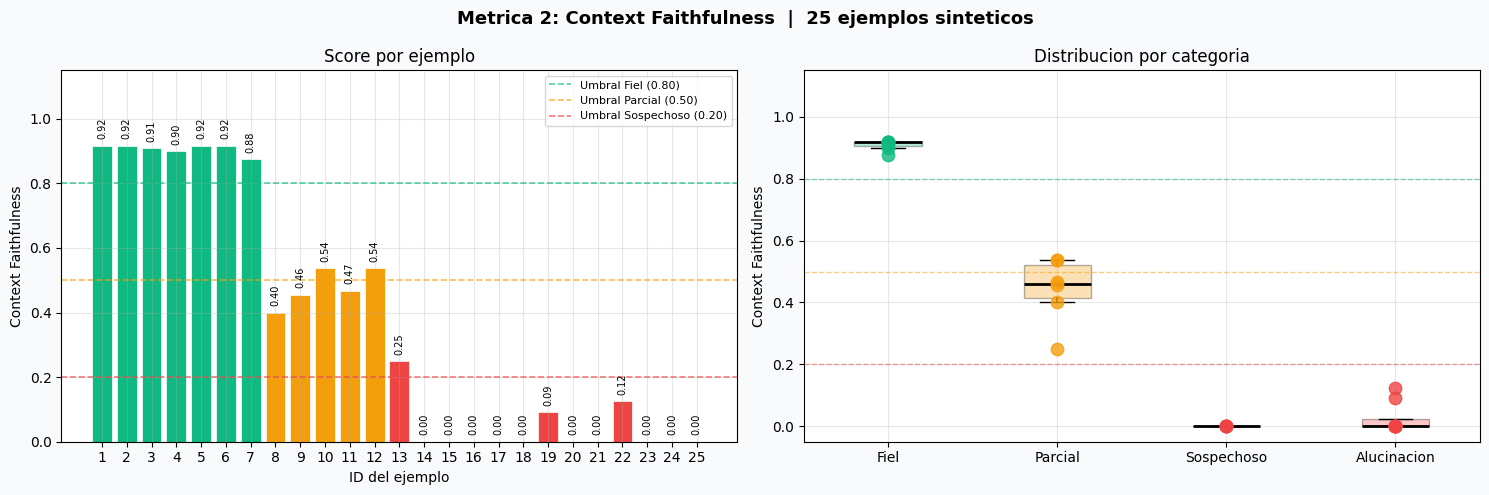

Promedio global: 0.369
  Fiel            n=7  media=0.907
  Parcial         n=6  media=0.441
  Sospechoso      n=4  media=0.000
  Alucinacion     n=8  media=0.027


In [10]:
# ── Visualizacion Context Faithfulness ───────────────────────────────────
scores_cf = [e['score'] for e in EJEMPLOS_CF]
ids_cf    = [e['id']    for e in EJEMPLOS_CF]
colores_cf = [color_score(s) for s in scores_cf]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Metrica 2: Context Faithfulness  |  25 ejemplos sinteticos',
             fontweight='bold', fontsize=13)

ax = axes[0]
bars = ax.bar(ids_cf, scores_cf, color=colores_cf, edgecolor='white', linewidth=0.5)
ax.axhline(0.80, color=VERDE, ls='--', lw=1.2, alpha=0.7, label='Umbral Fiel (0.80)')
ax.axhline(0.50, color=AMBAR, ls='--', lw=1.2, alpha=0.7, label='Umbral Parcial (0.50)')
ax.axhline(0.20, color=ROJO,  ls='--', lw=1.2, alpha=0.7, label='Umbral Sospechoso (0.20)')
ax.set_xlabel('ID del ejemplo')
ax.set_ylabel('Context Faithfulness')
ax.set_title('Score por ejemplo')
ax.set_ylim(0, 1.15)
ax.set_xticks(ids_cf)
ax.legend(fontsize=8)
for bar, score in zip(bars, scores_cf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax = axes[1]
orden_cf = ['Fiel', 'Parcial', 'Sospechoso', 'Alucinacion']
colores_c = {c: color_score({'Fiel':0.9,'Parcial':0.65,'Sospechoso':0.35,'Alucinacion':0.05}[c])
             for c in orden_cf}
for cat in orden_cf:
    vals = [e['score'] for e in EJEMPLOS_CF if e['categoria'] == cat]
    ax.scatter([cat]*len(vals), vals, color=colores_c[cat], s=80, alpha=0.8, zorder=3)
    ax.boxplot(vals, positions=[orden_cf.index(cat)], widths=0.4, patch_artist=True,
               boxprops=dict(facecolor=colores_c[cat], alpha=0.3),
               medianprops=dict(color='black', lw=2),
               whiskerprops=dict(lw=1.2), flierprops=dict(marker=''))
ax.set_xticks(range(len(orden_cf)))
ax.set_xticklabels(orden_cf)
ax.set_ylabel('Context Faithfulness')
ax.set_title('Distribucion por categoria')
ax.set_ylim(-0.05, 1.15)
ax.axhline(0.80, color=VERDE, ls='--', lw=1, alpha=0.5)
ax.axhline(0.50, color=AMBAR, ls='--', lw=1, alpha=0.5)
ax.axhline(0.20, color=ROJO,  ls='--', lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig('context_faithfulness.png', dpi=150, bbox_inches='tight')
plt.show()

print('Promedio global:', round(np.mean(scores_cf), 3))
for cat in orden_cf:
    vals = [e['score'] for e in EJEMPLOS_CF if e['categoria'] == cat]
    print(f'  {cat:15} n={len(vals)}  media={np.mean(vals):.3f}')


---
# Analisis combinado: las dos metricas juntas

Para combinar ambas metricas necesitamos ejemplos que tengan **las dos medidas al mismo tiempo**.  
Creamos un set de 20 casos combinados que ilustran los 4 cuadrantes del diagnostico.


In [11]:
# ── 20 casos combinados (TO + CF juntos) ─────────────────────────────────
CASOS_COMBO = [
  # Cuadrante OK: TO alto + CF alto (sistema funcionando bien)
  {"id": 1,  "ref": "Bruno Jose Bocanera DNI 31904457 Registro Notarial 11 Salta",
   "contexto": "Designase Escribano Bruno Jose Bocanera DNI 31904457 titular Registro Notarial 11 asiento ciudad Salta",
   "gen":     "El Escribano Bruno Jose Bocanera DNI 31904457 fue designado titular del Registro Notarial 11 en Salta."},
  {"id": 2,  "ref": "apercibimiento multa 50000 100000 unidades tributarias",
   "contexto": "responsable pasible apercibimiento multa 50000 100000 unidades tributarias suspension inmediata",
   "gen":     "La persona es pasible de apercibimiento y multa de entre 50000 y 100000 unidades tributarias."},
  {"id": 3,  "ref": "Legajo 13818 Cuerpo Seguridad Escalafon General",
   "contexto": "Figueroa Rueda DNI 27465890 Clase 1979 Legajo Personal 13818 Cuerpo Seguridad Escalafon General",
   "gen":     "Figueroa Rueda tiene Legajo 13818 del Cuerpo Seguridad Escalafon General."},
  {"id": 4,  "ref": "Testa Noelia Alejandra DNI 29640497 Concejo Deliberante diciembre 2025",
   "contexto": "afectacion Testa Noelia Alejandra DNI 29640497 Concejo Deliberante diciembre 2025 necesidades servicio",
   "gen":     "Noelia Alejandra Testa DNI 29640497 fue afectada al Concejo Deliberante hasta diciembre de 2025."},
  {"id": 5,  "ref": "Maria Veronica Saicha Ibanez DNI 20339284 Secretaria Justicia",
   "contexto": "Aceptase renuncia Dra Maria Veronica Saicha Ibanez DNI 20339284 cargo Secretaria Justicia",
   "gen":     "La Dra Maria Veronica Saicha Ibanez DNI 20339284 renuncio a Secretaria de Justicia."},

  # Cuadrante RETRIEVAL FALLA: TO bajo + CF alto (el LLM fue fiel al chunk pero el chunk era incorrecto)
  {"id": 6,  "ref": "Bruno Jose Bocanera DNI 31904457 Registro Notarial 11",
   "contexto": "Disponese Retiro Voluntario Suboficial Principal Figueroa Rueda DNI 27465890 Legajo 13818",
   "gen":     "El Suboficial Figueroa Rueda DNI 27465890 Legajo 13818 fue puesto en Retiro Voluntario."},
  {"id": 7,  "ref": "apercibimiento multa 50000 100000 unidades tributarias Ley 8488",
   "contexto": "afectacion Salazar Arce Carolina DNI 30221491 Concejo Deliberante enero diciembre 2025",
   "gen":     "La afectacion de Salazar Arce al Concejo Deliberante dura hasta diciembre de 2025."},
  {"id": 8,  "ref": "25122446 Legajo 13403 Clase 1976 Bonifacio",
   "contexto": "Claudia Elizabet Gomez Posse DNI 29164778 Legajo 13976 Clase 1982 Cuerpo Seguridad",
   "gen":     "La Suboficial Mayor Gomez Posse DNI 29164778 Legajo 13976 es de Clase 1982."},
  {"id": 9,  "ref": "31 diciembre 2025 afectacion Salazar Arce Concejo",
   "contexto": "SAENZ Villada Lopez Morillo Decreto 167 Bocanera Registro Notarial",
   "gen":     "El Decreto 167 designa al Escribano Bocanera como titular del Registro Notarial en Salta."},
  {"id": 10, "ref": "Saicha Ibanez renuncia Secretaria Justicia DNI 20339284",
   "contexto": "Legajo 13381 Clase 1970 Julio Blas Guaimas Cuerpo Seguridad Escalafon General",
   "gen":     "Julio Blas Guaimas tiene Legajo 13381 es de Clase 1970 del Cuerpo Seguridad Escalafon General."},

  # Cuadrante ALUCINACION CORRECTA: TO alto + CF bajo (el LLM acierta usando memoria, no el contexto)
  {"id": 11, "ref": "Bruno Jose Bocanera DNI 31904457 Registro Notarial 11",
   "contexto": "afectacion Testa Noelia Alejandra DNI 29640497 Concejo Deliberante diciembre 2025",
   "gen":     "El Escribano Bruno Jose Bocanera con DNI 31904457 fue designado titular del Registro Notarial 11."},
  {"id": 12, "ref": "apercibimiento multa 50000 100000 unidades tributarias",
   "contexto": "SAENZ Sola Usandivaras Lopez Morillo Decreto 172 retiro Salas",
   "gen":     "Las sanciones son apercibimiento y multa entre 50000 y 100000 unidades tributarias."},
  {"id": 13, "ref": "Maria Veronica Saicha Ibanez DNI 20339284 Secretaria Justicia",
   "contexto": "Suboficial Mayor Alberto Milagro Bonifacio DNI 25122446 Legajo 13403 Clase 1976",
   "gen":     "La Dra Maria Veronica Saicha Ibanez DNI 20339284 renuncio al cargo de Secretaria de Justicia."},
  {"id": 14, "ref": "31 diciembre 2025 necesidades servicio Salazar Arce",
   "contexto": "Legajo 13510 Javier Alberto Flores Cabana DNI 22945314 Clase 1972 Seguridad",
   "gen":     "La afectacion de Salazar Arce al Concejo Deliberante dura hasta el 31 de diciembre de 2025."},
  {"id": 15, "ref": "Legajo 13818 Cuerpo Seguridad Escalafon General Figueroa",
   "contexto": "Boletin Oficial Salta Edicion 21922 lunes 31 marzo 2025 publicacion",
   "gen":     "El Suboficial Principal Carlos Figueroa Rueda tiene Legajo 13818 Cuerpo Seguridad Escalafon General."},

  # Cuadrante FALLO TOTAL: TO bajo + CF bajo (retrieval pobre y LLM alucina)
  {"id": 16, "ref": "Bruno Jose Bocanera DNI 31904457 Registro Notarial 11",
   "contexto": "Edicion 21922 Boletin Oficial Salta publicacion 31/03/2025",
   "gen":     "El Escribano Carlos Gonzalez DNI 99999999 fue designado titular del Registro N 5 en Rosario."},
  {"id": 17, "ref": "apercibimiento multa 50000 100000 unidades tributarias suspension",
   "contexto": "Decreto Reglamentario 571/2020 28/08/2020 Gobernacion",
   "gen":     "La sancion es una multa de 500000 pesos y la inhabilitacion del establecimiento por 6 meses."},
  {"id": 18, "ref": "Legajo 13818 Cuerpo Seguridad Escalafon General",
   "contexto": "publicacion 31/03/2025 pagina boletin oficial",
   "gen":     "El agente tiene Legajo 99999 del Cuerpo Administrativo Escalafon Tecnico Profesional."},
  {"id": 19, "ref": "31 diciembre 2025 necesidades servicio Salazar Arce Concejo",
   "contexto": "Decreto 571/2020 reglamentario gobernacion salta agosto",
   "gen":     "La afectacion vence el 30 de junio de 2026 segun el plan anual de afectaciones del ministerio."},
  {"id": 20, "ref": "Maria Veronica Saicha Ibanez DNI 20339284 Secretaria Justicia renuncia",
   "contexto": "pagina 18 boletin oficial edicion salta lunes marzo",
   "gen":     "La Dra Sofia Martinez DNI 11111111 fue designada nueva Secretaria de Justicia por Decreto 200."},
]

# Calcular ambas metricas para cada caso combinado
for c in CASOS_COMBO:
    c['to']  = token_overlap(c['gen'], c['ref'])
    c['cf']  = context_faithfulness(c['gen'], c['contexto'])

print('Casos combinados calculados')
print(f"{'ID':>3}  {'TO':>6}  {'CF':>6}  Cuadrante")
print('-' * 45)
for c in CASOS_COMBO:
    q = ('OK' if c['to']>=0.5 and c['cf']>=0.5 else
         'Retrieval falla'    if c['to']<0.5  and c['cf']>=0.5 else
         'Alucinacion correcta' if c['to']>=0.5 and c['cf']<0.5  else
         'Fallo total')
    print(f"{c['id']:>3}  {c['to']:>6.3f}  {c['cf']:>6.3f}  {q}")


Casos combinados calculados
 ID      TO      CF  Cuadrante
---------------------------------------------
  1   1.000   0.909  OK
  2   1.000   0.778  OK
  3   1.000   0.889  OK
  4   1.000   0.900  OK
  5   1.000   0.900  OK
  6   0.143   0.900  Retrieval falla
  7   0.000   0.875  Retrieval falla
  8   0.333   0.800  Retrieval falla
  9   0.000   0.556  Retrieval falla
 10   0.000   0.917  Retrieval falla
 11   1.000   0.091  Alucinacion correcta
 12   1.000   0.000  Alucinacion correcta
 13   1.000   0.091  Alucinacion correcta
 14   0.667   0.000  Alucinacion correcta
 15   1.000   0.000  Alucinacion correcta
 16   0.286   0.000  Fallo total
 17   0.143   0.000  Fallo total
 18   0.500   0.000  Alucinacion correcta
 19   0.000   0.000  Fallo total
 20   0.333   0.000  Fallo total


### Diagrama de dispersion: los 4 cuadrantes

Este grafico es la herramienta de diagnostico central:  
cada punto es un ejemplo, su posicion revela exactamente **que tipo de fallo** tiene el sistema.


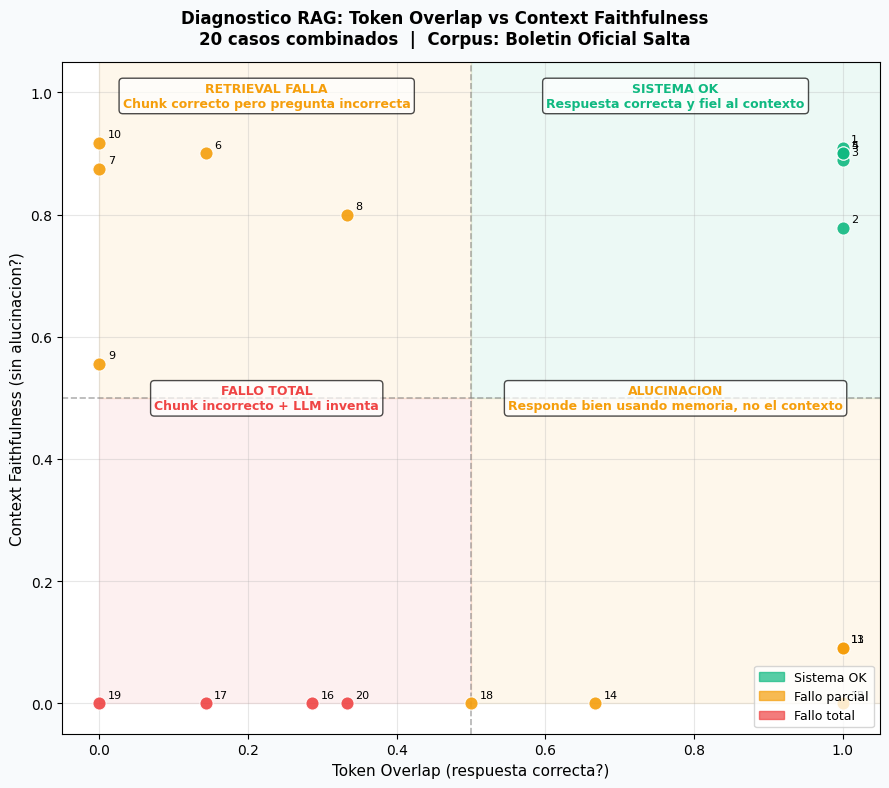

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))
fig.suptitle('Diagnostico RAG: Token Overlap vs Context Faithfulness\n'
             '20 casos combinados  |  Corpus: Boletin Oficial Salta',
             fontweight='bold', fontsize=12)

# Fondo de cuadrantes
ax.fill_between([0.5, 1.05], [0.5, 0.5], [1.05, 1.05], alpha=0.08, color=VERDE)
ax.fill_between([0,   0.5],  [0.5, 0.5], [1.05, 1.05], alpha=0.08, color=AMBAR)
ax.fill_between([0.5, 1.05], [0,   0],   [0.5,  0.5],  alpha=0.08, color=AMBAR)
ax.fill_between([0,   0.5],  [0,   0],   [0.5,  0.5],  alpha=0.08, color=ROJO)

# Lineas divisorias
ax.axvline(0.5, color='gray', ls='--', lw=1.2, alpha=0.6)
ax.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.6)

# Etiquetas de cuadrantes
fs = 9
ax.text(0.75, 0.97, 'SISTEMA OK\nRespuesta correcta y fiel al contexto',
        ha='center', va='top', fontsize=fs, color=VERDE, fontweight='bold',
        transform=ax.transAxes, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax.text(0.25, 0.97, 'RETRIEVAL FALLA\nChunk correcto pero pregunta incorrecta',
        ha='center', va='top', fontsize=fs, color=AMBAR, fontweight='bold',
        transform=ax.transAxes, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax.text(0.75, 0.52, 'ALUCINACION\nResponde bien usando memoria, no el contexto',
        ha='center', va='top', fontsize=fs, color=AMBAR, fontweight='bold',
        transform=ax.transAxes, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax.text(0.25, 0.52, 'FALLO TOTAL\nChunk incorrecto + LLM inventa',
        ha='center', va='top', fontsize=fs, color=ROJO, fontweight='bold',
        transform=ax.transAxes, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# Puntos
for c in CASOS_COMBO:
    col = (VERDE if c['to']>=0.5 and c['cf']>=0.5 else
           AMBAR if c['to']>=0.5 or  c['cf']>=0.5 else ROJO)
    ax.scatter(c['to'], c['cf'], color=col, s=90, zorder=5, alpha=0.9, edgecolors='white', lw=0.8)
    ax.annotate(str(c['id']), (c['to'], c['cf']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('Token Overlap (respuesta correcta?)', fontsize=11)
ax.set_ylabel('Context Faithfulness (sin alucinacion?)', fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

parches = [
    mpatches.Patch(color=VERDE, alpha=0.7, label='Sistema OK'),
    mpatches.Patch(color=AMBAR, alpha=0.7, label='Fallo parcial'),
    mpatches.Patch(color=ROJO,  alpha=0.7, label='Fallo total'),
]
ax.legend(handles=parches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('diagnostico_rag.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Tabla de diagnostico y acciones

El cuadrante en el que cae un sistema define exactamente que hay que mejorar.


In [13]:
TABLA = [
    {'Cuadrante': 'TO alto + CF alto',
     'Estado': 'Sistema OK',
     'Causa': 'Retrieval y generacion correctos',
     'Accion': 'Mantener. Subir el umbral para exigir mas.'},
    {'Cuadrante': 'TO bajo  + CF alto',
     'Estado': 'Retrieval falla',
     'Causa': 'El LLM uso el contexto pero el chunk era incorrecto',
     'Accion': 'Revisar chunking, segmentacion y estrategia de embedding.'},
    {'Cuadrante': 'TO alto  + CF bajo',
     'Estado': 'Alucinacion correcta',
     'Causa': 'El LLM acierta usando su memoria, no el contexto',
     'Accion': 'Reforzar system prompt. Si el doc se actualiza, el sistema falla en silencio.'},
    {'Cuadrante': 'TO bajo  + CF bajo',
     'Estado': 'Fallo total',
     'Causa': 'Chunk incorrecto y el LLM invento encima',
     'Accion': 'Revisar todo el pipeline desde la ingesta.'},
]

df_tabla = pd.DataFrame(TABLA)
print(df_tabla.to_string(index=False))


         Cuadrante               Estado                                               Causa                                                                        Accion
 TO alto + CF alto           Sistema OK                    Retrieval y generacion correctos                                    Mantener. Subir el umbral para exigir mas.
TO bajo  + CF alto      Retrieval falla El LLM uso el contexto pero el chunk era incorrecto                     Revisar chunking, segmentacion y estrategia de embedding.
TO alto  + CF bajo Alucinacion correcta    El LLM acierta usando su memoria, no el contexto Reforzar system prompt. Si el doc se actualiza, el sistema falla en silencio.
TO bajo  + CF bajo          Fallo total            Chunk incorrecto y el LLM invento encima                                    Revisar todo el pipeline desde la ingesta.


---
## Resumen de la clase

```
LO QUE MEDIMOS

  Token Overlap:         tokens(GEN) ∩ tokens(REF)   /  tokens(REF)
  Context Faithfulness:  tokens(GEN) ∩ tokens(CTX)   /  tokens(GEN)

LO QUE DETECTAMOS

  TO alto + CF alto   ->  Sistema funcionando bien
  TO bajo + CF alto   ->  Problema de retrieval (chunk equivocado)
  TO alto + CF bajo   ->  LLM usa memoria en lugar del contexto (peligroso)
  TO bajo + CF bajo   ->  Fallo total, revisar desde ingesta


```
